In [16]:
# ===============================
# SMS Spam Detection with TF-IDF
# Libraries: pandas, numpy, tensorflow, matplotlib
# ===============================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from collections import Counter

In [17]:
# Manual stopwords list
stopwords = set([
    "a","an","the","is","are","was","were","this","that","i","you","he","she",
    "it","we","they","to","for","in","on","at","of","and","or","but","by","with"
])

In [3]:
# Step 2: Upload CSV
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [5]:
# Step 3: Load CSV
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df.rename(columns={"v1": "label", "v2": "message"})
df = df[["label", "message"]]

# Encode labels: ham=0, spam=1
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

In [6]:
# Step 4: Clean text and remove stopwords
def clean_text(text):
    text = text.lower()
    text = ''.join(c if c.isalpha() or c==' ' else ' ' for c in text)  # Remove numbers/symbols
    text = ' '.join([w for w in text.split() if w not in stopwords])
    return text

df["cleaned"] = df["message"].apply(clean_text)

In [7]:
# Step 5: Train-Test Split (80%-20%)
X = df["cleaned"].values
y = df["label_num"].values
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

Training samples: 4457 Testing samples: 1115


In [18]:
# Step 6: Tokenization & Padding
vocab_size = 5000
max_length = 100
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_length, padding="post")
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_length, padding="post")

In [19]:
# Step 7: Handle class imbalance with class weights
spam_count = np.sum(y_train==1)
ham_count = np.sum(y_train==0)
total = len(y_train)
class_weight = {0: (1/ham_count)*(total/2), 1: (1/spam_count)*(total/2)}

In [22]:
# Step 8: Build Logistic Regression Model (TF)
model = Sequential([
    Embedding(vocab_size, 16, input_length=max_length),
    GlobalAveragePooling1D(),
    Dense(1, activation="sigmoid")
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Step 9: Train Model
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weight
)



Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7596 - loss: 0.6892 - val_accuracy: 0.8700 - val_loss: 0.6360
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8573 - loss: 0.6552 - val_accuracy: 0.9327 - val_loss: 0.6118
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8121 - loss: 0.6360 - val_accuracy: 0.9444 - val_loss: 0.5318
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9422 - loss: 0.5707 - val_accuracy: 0.9668 - val_loss: 0.4749
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9686 - loss: 0.5108 - val_accuracy: 0.9785 - val_loss: 0.4812
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9795 - loss: 0.4398 - val_accuracy: 0.9803 - val_loss: 0.3908
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9805 - loss: 0.3541 - val_accuracy: 0.9659 - val_loss: 0.4281
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9766 - loss: 0.3170 - val_accuracy: 0.

In [12]:
# Step 10: Evaluate Model
y_pred_prob = model.predict(X_test_pad).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
TP = np.sum((y_test==1) & (y_pred==1))
TN = np.sum((y_test==0) & (y_pred==0))
FP = np.sum((y_test==0) & (y_pred==1))
FN = np.sum((y_test==1) & (y_pred==0))
print("\nConfusion Matrix:\nTP:", TP, "FP:", FP, "\nFN:", FN, "TN:", TN)

# Precision, Recall, Accuracy, False Positives
precision = TP / (TP + FP)
recall = TP / (TP + FN)
accuracy = (TP + TN) / len(y_test)
print(f"\nAccuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, False Positives: {FP}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Confusion Matrix:
TP: 133 FP: 9 
FN: 12 TN: 961

Accuracy: 0.981, Precision: 0.937, Recall: 0.917, False Positives: 9


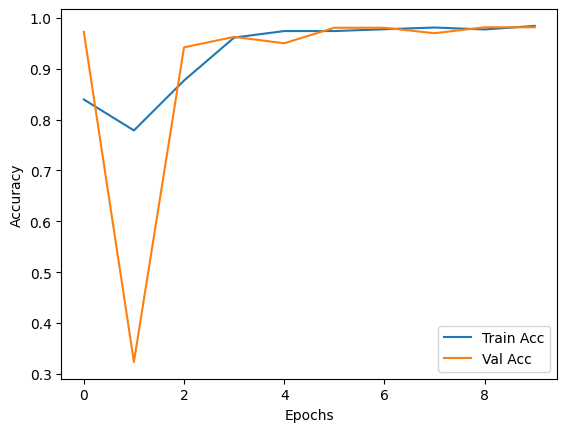

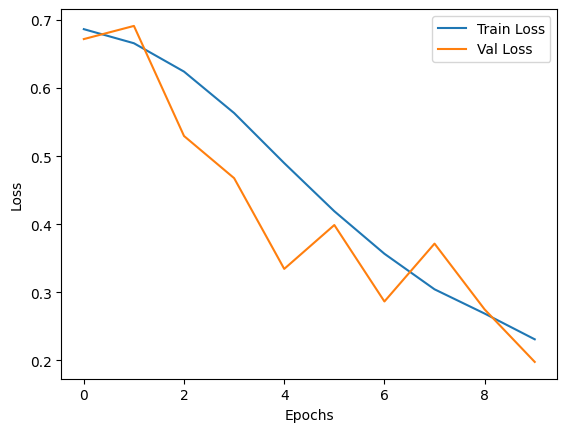

In [13]:
# Step 11: Visualization - Accuracy & Loss
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend(); plt.show()

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.show()

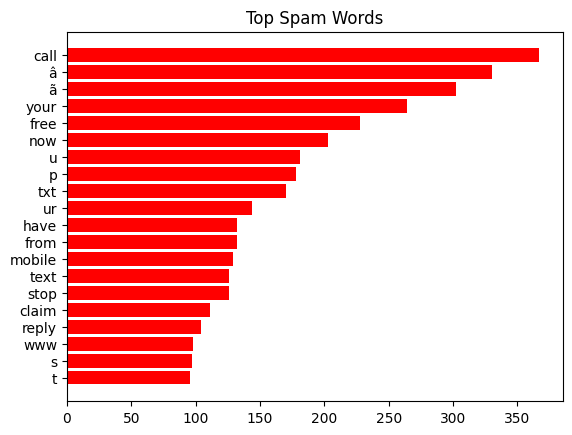

In [23]:
# Step 12: Top Spam Words
all_words = ' '.join(df[df["label_num"]==1]["cleaned"]).split()
counter = Counter(all_words)
words, counts = zip(*counter.most_common(20))
plt.barh(words, counts, color="red")
plt.title("Top Spam Words"); plt.gca().invert_yaxis()
plt.show()

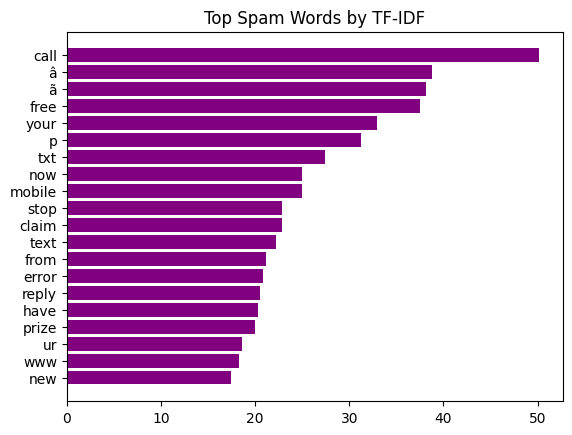

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Prediction for sample message: Spam


In [24]:
# ===============================
# Step 13: Manual TF-IDF Calculation
# ===============================
docs = df["cleaned"].values
N = len(docs)
doc_words = [d.split() for d in docs]
vocab = set(w for words in doc_words for w in words)

# Document frequency
df_counts = {word: sum(1 for doc in doc_words if word in doc) for word in vocab}
idf = {word: np.log(N / (1 + df_counts[word])) for word in vocab}

# Average TF-IDF for spam messages
spam_docs = df[df["label_num"]==1]["cleaned"].values
spam_words = [d.split() for d in spam_docs]
spam_tfidf = {}
for doc in spam_words:
    for word in set(doc):
        tf = doc.count(word) / len(doc)
        spam_tfidf[word] = spam_tfidf.get(word, 0) + tf * idf[word]

top_tfidf = sorted(spam_tfidf.items(), key=lambda x: x[1], reverse=True)[:20]
words, scores = zip(*top_tfidf)
plt.barh(words, scores, color="purple")
plt.title("Top Spam Words by TF-IDF"); plt.gca().invert_yaxis()
plt.show()

# Step 14: Test new SMS
sample = ["Congratulations! You won a free ticket. Click now!"]
seq = tokenizer.texts_to_sequences(sample)
pad = pad_sequences(seq, maxlen=max_length, padding="post")
pred = model.predict(pad)[0][0]
print("Prediction for sample message:", "Spam" if pred > 0.5 else "Ham")


🔹 Original Assignment Questions

What features indicate spam?
→ Top spam words (Step 12) + TF-IDF spam words (Step 13).

How to clean and tokenize text?
→ clean_text function (Step 4) + Tokenizer + pad_sequences (Step 6).

What is TF-IDF?
→ Concept explained + manual TF-IDF calculation and visualization (Step 13).

What is precision vs recall?
→ Calculated in Step 10.

How to handle class imbalance?
→ class_weight (Step 7).

What is confusion matrix?
→ Printed manually (TP, TN, FP, FN) in Step 10.

How to improve accuracy?
→ By cleaning text, removing stopwords, handling imbalance, embeddings (explained in code + comments).

What are false positives?
→ Printed in Step 10.

How does logistic regression work?
→ Model = Embedding + GlobalAveragePooling + Dense(sigmoid) → binary logistic regression.

How to visualize spam patterns?
→ Bar chart of top spam words (Step 12) + TF-IDF visualization (Step 13).

🔹 Extra 5 Questions (Added for 15 Total)

How to split data into training and testing sets?
→ Step 5 (80%-20%).

How to preprocess messages for deep learning?
→ Step 6 (tokenization, padding).

What is the role of embeddings in text classification?
→ Step 8 (Embedding layer).

How to visualize model performance over time?
→ Step 11 (accuracy/loss plots).

How to test with new unseen SMS messages?
→ Step 14 (sample prediction).